# FIFA World Cup 2026 – Defensive Performance Analysis

## Defending Analysis

### Analytic Question

Among eligible players in the FIFA World Cup 2026, what was the average number of tackles won plus interceptions per 90 minutes, and was there a statistically significant difference between defenders and midfielders?

### Main Metric

Defensive Actions per 90 = (Tackles Won + Interceptions) / 90s

Where:
- TklW = Tackles Won
- Int = Interceptions
- 90s = Playing time measured in 90-minute units

### Data Source

FBref – FIFA World Cup 2026 Defensive Actions statistics.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
file_path = "sportsref_download.xls.csv"

df = pd.read_csv(file_path, skiprows=1)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 499
Columns: 24


In [5]:
df.head()

,Rk,Player,Pos,Squad,Age,Born,90s,Tkl,TklW,Def 3rd,...,Tkl%,Lost,Blocks,Sh,Pass,Int,Tkl+Int,Clr,Err,Matches
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,Matches
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,Matches
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,Matches
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,Matches
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,Matches


In [6]:
print(df.columns.tolist())

['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Tkl.1', 'Att', 'Tkl%', 'Lost', 'Blocks', 'Sh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Matches']


In [7]:
defense = df[["Player", "Pos", "Squad", "Age", "90s", "TklW", "Int"]].copy()

defense.head()

,Player,Pos,Squad,Age,90s,TklW,Int
0,Brenden Aaronson,MF,us USA,25,0.8,1,0
1,Thelo Aasgaard,MF,no Norway,24,1.0,1,3
2,Hamza Abdelkarim,FW,eg Egypt,18,0.7,0,0
3,Hossam Abdelmaguid,DF,eg Egypt,25,0.7,0,1
4,Mohamed Abdelmonem,DF,eg Egypt,27,0.2,0,0


In [11]:
#CHECKING MISSING VALUES
print("Missing values:")
print(defense.isnull().sum())

#checking positions
print(defense["Pos"].value_counts())

#checking duplicates
print("Duplicate rows:", defense.duplicated().sum())

#checking the data types
print(defense.dtypes)

Missing values:
Player    0
Pos       0
Squad     0
Age       0
90s       0
TklW      0
Int       0
dtype: int64
Pos
MF       163
DF       150
FW        82
FW,MF     38
GK        26
MF,FW     16
DF,MF     15
MF,DF      7
DF,FW      2
Name: count, dtype: int64
Duplicate rows: 0
Player        str
Pos           str
Squad         str
Age         int64
90s       float64
TklW        int64
Int         int64
dtype: object


In [12]:
# Use the first listed position as the player's main position
defense["Main_Pos"] = defense["Pos"].str.split(",").str[0]

print(defense["Main_Pos"].value_counts())

Main_Pos
MF    186
DF    167
FW    120
GK     26
Name: count, dtype: int64


In [13]:
# only keeping defenders and midfielders
defense = defense[defense["Main_Pos"].isin(["DF", "MF"])].copy()

print("Players remaining:", len(defense))
print(defense["Main_Pos"].value_counts())

Players remaining: 353
Main_Pos
MF    186
DF    167
Name: count, dtype: int64


In [14]:
# only keeping players who played at least 90 minutes
eligible = defense[defense["90s"] >= 1].copy()

print("Eligible players:", len(eligible))
print(eligible["Main_Pos"].value_counts())

Eligible players: 276
Main_Pos
MF    146
DF    130
Name: count, dtype: int64


In [15]:
# calculating tackles won + interceptions per 90
eligible["Def_Actions_90"] = (eligible["TklW"] + eligible["Int"]) / eligible["90s"]

eligible[["Player", "Main_Pos", "90s", "TklW", "Int", "Def_Actions_90"]].head(10)

,Player,Main_Pos,90s,TklW,Int,Def_Actions_90
1,Thelo Aasgaard,MF,1.0,1,3,4.000000
5,Ali Abdi,DF,3.0,8,4,4.000000
6,Saud Abdulhamid,DF,3.0,9,2,3.666667
7,Abdulla Abdullaev,DF,2.0,2,3,2.500000
9,Husam Abu Dahab,DF,2.0,3,0,1.500000
11,Mohannad Abu Taha,DF,2.9,2,6,2.758621
17,Jayden Adams,MF,1.3,0,2,1.538462
18,Tyler Adams,MF,3.8,5,8,3.421053
19,Ricardo AdÃ©,DF,3.0,2,5,2.333333
22,Jonas Adjetey,DF,2.5,3,1,1.600000


In [16]:
print(eligible["Def_Actions_90"].describe())

count    276.000000
mean       2.050855
std        1.150336
min        0.000000
25%        1.176471
50%        1.867733
75%        2.708845
max        6.000000
Name: Def_Actions_90, dtype: float64


## Population and Sampling

The population for this analysis consists of eligible defenders and midfielders who played at least 90 minutes in the FIFA World Cup 2026 dataset.

After applying the eligibility criteria, 276 players remained:
- 130 defenders
- 146 midfielders

A stratified random sampling approach was used to ensure that both positional groups were represented equally. A random sample of 40 defenders and 40 midfielders was selected, giving a total sample size of 80 players.

A random seed was used so that the same sample could be reproduced.

In [17]:
# separating defenders and midfielders
defenders = eligible[eligible["Main_Pos"] == "DF"]
midfielders = eligible[eligible["Main_Pos"] == "MF"]

print("Defenders:", len(defenders))
print("Midfielders:", len(midfielders))

Defenders: 130
Midfielders: 146


In [18]:
# taking 40 random players from each position
sample_df = defenders.sample(n=40, random_state=42)
sample_mf = midfielders.sample(n=40, random_state=42)

# combining both groups into one sample
sample = pd.concat([sample_df, sample_mf])

print("Total sample:", len(sample))
print(sample["Main_Pos"].value_counts())

Total sample: 80
Main_Pos
DF    40
MF    40
Name: count, dtype: int64


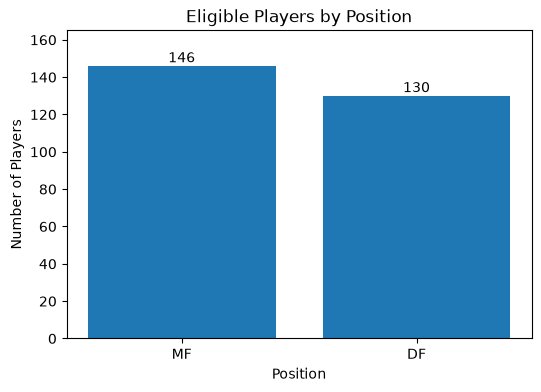

In [31]:
# showing the number of eligible players in each position
position_counts = eligible["Main_Pos"].value_counts()

plt.figure(figsize=(6, 4))

bars = plt.bar(position_counts.index, position_counts.values)

# adding the number above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
        height + 2,
        int(height),
        ha="center")

plt.title("Eligible Players by Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.ylim(0, 165)

plt.show()

## Descriptive Statistics

Descriptive statistics were used to summarise the defensive performance of the sampled players. The mean, median, standard deviation, quartiles, minimum and maximum were calculated for defensive actions per 90 minutes.

The results were also compared between defenders and midfielders.

In [19]:
# descriptive statistics for the whole sample
sample["Def_Actions_90"].describe()

count    80.000000
mean      2.102190
std       1.172175
min       0.000000
25%       1.173051
50%       1.975610
75%       2.689655
max       6.000000
Name: Def_Actions_90, dtype: float64

In [20]:
overall_stats = {
    "Count": len(sample),
    "Mean": sample["Def_Actions_90"].mean(),
    "Median": sample["Def_Actions_90"].median(),
    "Std Dev": sample["Def_Actions_90"].std(),
    "Minimum": sample["Def_Actions_90"].min(),
    "Q1": sample["Def_Actions_90"].quantile(0.25),
    "Q3": sample["Def_Actions_90"].quantile(0.75),
    "Maximum": sample["Def_Actions_90"].max()
}

pd.Series(overall_stats).round(3)

Count      80.000
Mean        2.102
Median      1.976
Std Dev     1.172
Minimum     0.000
Q1          1.173
Q3          2.690
Maximum     6.000
dtype: float64

In [21]:
# comparing the two positions
group_stats = sample.groupby("Main_Pos")["Def_Actions_90"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

group_stats.round(3)

,count,mean,median,std,min,max
Main_Pos,,,,,,
DF,40,2.375,2.222,1.058,1.0,6.000
MF,40,1.829,1.499,1.229,0.0,4.615


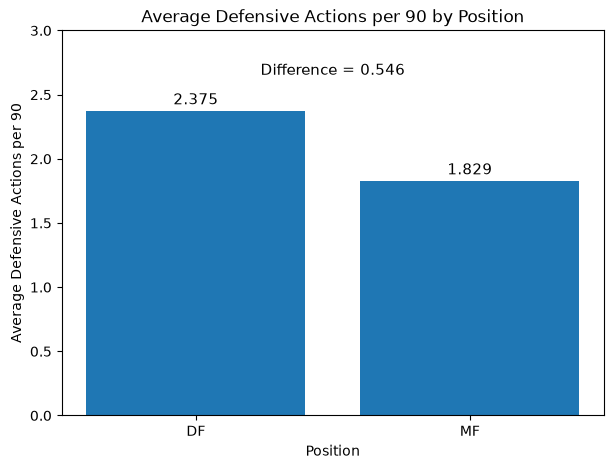

In [39]:
# average defensive actions by position
position_means = sample.groupby("Main_Pos")["Def_Actions_90"].mean()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    position_means.index,
    position_means.values
)

# add exact mean values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.3f}",
        ha="center",
        fontsize=11
    )

# show the difference between the two means
difference = position_means["DF"] - position_means["MF"]

plt.text(
    0.5,
    max(position_means.values) + 0.28,
    f"Difference = {difference:.3f}",
    ha="center",
    fontsize=11
)

plt.title("Average Defensive Actions per 90 by Position")
plt.xlabel("Position")
plt.ylabel("Average Defensive Actions per 90")
plt.ylim(0, 3)

plt.show()

## 95% Confidence Interval

A 95% confidence interval was calculated to estimate the population mean for defensive actions per 90 minutes.

The confidence interval provides a range of plausible values for the true population mean based on the sample.

In [23]:
# calculating the 95% confidence interval
data = sample["Def_Actions_90"]

mean = data.mean()
std = data.std()
n = len(data)

standard_error = std / np.sqrt(n)
t_value = stats.t.ppf(0.975, df=n-1)

margin_error = t_value * standard_error

lower_ci = mean - margin_error
upper_ci = mean + margin_error

print("Sample mean:", round(mean, 3))
print("95% CI:", round(lower_ci, 3), "to", round(upper_ci, 3))

Sample mean: 2.102
95% CI: 1.841 to 2.363


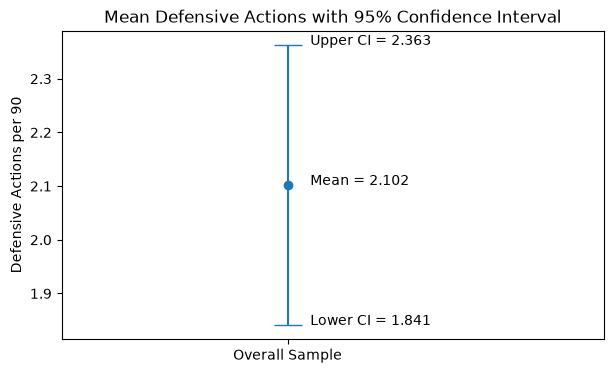

In [41]:
# visualising the 95% confidence interval
plt.figure(figsize=(7, 4))

plt.errorbar(
    1, mean,
    yerr=[[mean - lower_ci], [upper_ci - mean]],
    fmt="o",
    capsize=10
)

plt.text(1.05, mean, f"Mean = {mean:.3f}")
plt.text(1.05, lower_ci, f"Lower CI = {lower_ci:.3f}")
plt.text(1.05, upper_ci, f"Upper CI = {upper_ci:.3f}")

plt.xlim(0.5, 1.7)
plt.xticks([1], ["Overall Sample"])
plt.ylabel("Defensive Actions per 90")
plt.title("Mean Defensive Actions with 95% Confidence Interval")

plt.show()

Based on the sample, the true population mean of defensive actions per 90 is estimated to lie between approximately 1.84 and 2.36 with 95% confidence.

## Two-Sample t-Test

A two-sample t-test was used to compare the average defensive actions per 90 between defenders and midfielders.

### Hypotheses

Null hypothesis (H0): There is no significant difference in the average defensive actions per 90 between defenders and midfielders.

Alternative hypothesis (H1): There is a significant difference in the average defensive actions per 90 between defenders and midfielders.

The significance level for this test is 0.05.

In [24]:
# getting defensive action values for both groups
df_values = sample_df["Def_Actions_90"]
mf_values = sample_mf["Def_Actions_90"]

print("Defender mean:", round(df_values.mean(), 3))
print("Midfielder mean:", round(mf_values.mean(), 3))

Defender mean: 2.375
Midfielder mean: 1.829


In [25]:
# two-sample t-test
t_stat, p_value = stats.ttest_ind(
    df_values,
    mf_values,
    equal_var=False
)

print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))

t-statistic: 2.128
p-value: 0.0366


### T-test Result

The t-test gave a t-statistic of 2.128 and a p-value of 0.0366.

Since the p-value is less than 0.05, the null hypothesis is rejected. This means there is a statistically significant difference in the average defensive actions per 90 between defenders and midfielders.

Defenders had a higher average of 2.375 defensive actions per 90 compared to 1.829 for midfielders.

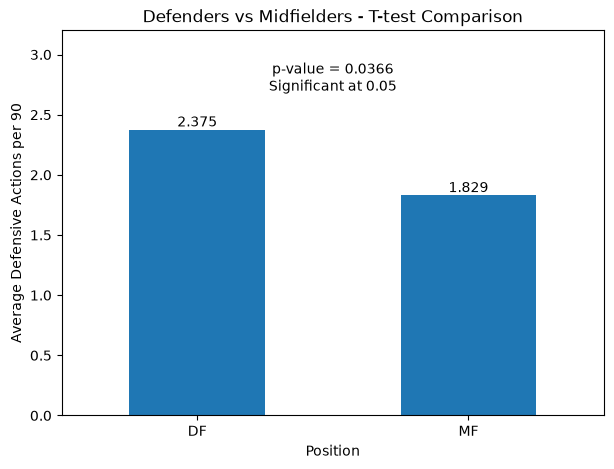

In [44]:
# visualising the t-test result
position_means = sample.groupby("Main_Pos")["Def_Actions_90"].mean()

ax = position_means.plot(kind="bar", figsize=(7, 5))

plt.title("Defenders vs Midfielders - T-test Comparison")
plt.xlabel("Position")
plt.ylabel("Average Defensive Actions per 90")
plt.xticks(rotation=0)

# show mean values
ax.bar_label(ax.containers[0], fmt="%.3f")

# show t-test result
plt.text(
    0.5, 2.7,
    f"p-value = {p_value:.4f}\nSignificant at 0.05",
    ha="center"
)

plt.ylim(0, 3.2)
plt.show()